## Model Development

### Import

In [1]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

### Dataset Class

In [2]:
class BeforeAfterDataset(Dataset):
    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)
        self.base_path = "../Images"
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])

    def get_image_path(self, filename, label):
        if label == 1:
            folder = "Rhinoplasty"
        else:
            folder = "Aging Images"
        
        return os.path.join(self.base_path, folder, filename)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        before_path = self.get_image_path(row['before_image'], row['label'])
        after_path = self.get_image_path(row['after_image'], row['label'])

        before_img = Image.open(before_path).convert("RGB")
        after_img = Image.open(after_path).convert("RGB")

        before_img = self.transform(before_img)
        after_img = self.transform(after_img)

        label = int(row['label'])

        return before_img, after_img, label

### Loading Dataset + DataLoader

In [3]:
dataset = BeforeAfterDataset("../Data/dataset.csv")

print("Dataset size:", len(dataset))

before, after, label = dataset[0]
print("Shape:", before.shape, after.shape, "Label:", label)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

Dataset size: 15
Shape: torch.Size([3, 224, 224]) torch.Size([3, 224, 224]) Label: 1


### Model

In [4]:
class DifferenceModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()  # remove classifier
        
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, before, after):
        f1 = self.resnet(before)
        f2 = self.resnet(after)
        
        diff = f2 - f1
        
        return self.classifier(diff)

### Training

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DifferenceModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for before, after, labels in loader:
        before = before.to(device)
        after = after.to(device)
        labels = labels.to(device)

        outputs = model(before, after)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15, Loss: 2.9644
Epoch 2/15, Loss: 1.7180
Epoch 3/15, Loss: 0.7926
Epoch 4/15, Loss: 0.5571
Epoch 5/15, Loss: 0.3383
Epoch 6/15, Loss: 0.1742
Epoch 7/15, Loss: 0.7066
Epoch 8/15, Loss: 0.5623
Epoch 9/15, Loss: 0.0737
Epoch 10/15, Loss: 0.0673
Epoch 11/15, Loss: 0.0999
Epoch 12/15, Loss: 1.0241
Epoch 13/15, Loss: 0.0978
Epoch 14/15, Loss: 0.4228
Epoch 15/15, Loss: 0.1760


### Evaluation

In [6]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for before, after, labels in loader:
        before = before.to(device)
        after = after.to(device)
        labels = labels.to(device)

        outputs = model(before, after)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


### Prediction

In [7]:
def predict_sample(model, dataset, idx):
    model.eval()
    
    before, after, label = dataset[idx]
    
    before = before.unsqueeze(0).to(device)
    after = after.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(before, after)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    
    classes = ["Aging", "Rhinoplasty"]
    
    print("----- Prediction -----")
    print(f"Actual: {classes[label]}")
    print(f"Predicted: {classes[pred]}")
    print(f"Confidence: {probs[0][pred].item():.2f}")

predict_sample(model, dataset, idx=0)

----- Prediction -----
Actual: Rhinoplasty
Predicted: Rhinoplasty
Confidence: 1.00


### Image Prediction

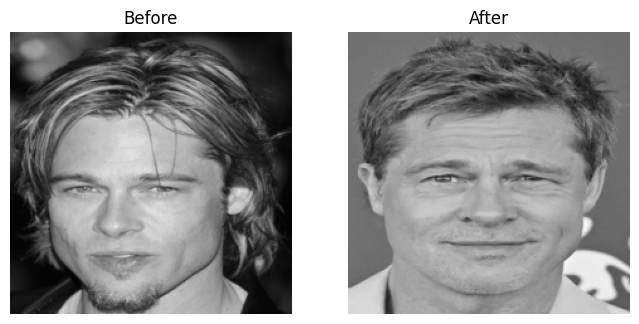

----- Prediction -----
Actual: Aging
Predicted: Aging
Confidence: 1.00


In [8]:
import matplotlib.pyplot as plt

def show_sample(dataset, idx):
    before, after, label = dataset[idx]
    
    before = before.permute(1, 2, 0)
    after = after.permute(1, 2, 0)
    
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.imshow(before)
    plt.title("Before")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(after)
    plt.title("After")
    plt.axis("off")
    
    plt.show()

idx = 14

show_sample(dataset, idx)
predict_sample(model, dataset, idx)